<a href="https://colab.research.google.com/github/biopharma26/PracticeNotebooks/blob/main/p301_Transcriptomics_DEG_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01 — Transcriptomics: Taxane-Induced DEG / Volcano Analysis

**Project:** Precision Oncology Mechanisms of Pacific Yew Taxanes
**Section mirrored:** Report §1–2 (G2/M arrest biomarkers) and Figure 2 (DEG volcano plot)

**What this notebook actually does**

The uploaded report presents a volcano plot of taxane-induced differentially expressed genes (DEGs) with
specific fold-changes and p-values, but gives no underlying count matrix, cohort, or DE method — those
numbers cannot be reproduced or verified as written. This notebook gives you a **working, swappable
pipeline** instead:

1. A clearly-labeled **synthetic RNA-seq count matrix** (tumor vs. taxane-treated) built around the gene set
   named in the report, so the whole pipeline runs end-to-end out of the box.
2. A real differential-expression routine (Welch's t-test + log2FC + Benjamini–Hochberg FDR) — the standard
   approach when you don't have DESeq2/R available in the Colab Python runtime.
3. A **drop-in slot** (Section 2) to replace the synthetic matrix with your own TCGA / GEO / in-house counts —
   at that point the volcano plot and gene calls become real results, not illustrations.

> ⚠️ **Until you load real counts in Section 2, every number downstream is simulated for demonstration only —
> do not cite it.**


In [1]:
# --- Setup ---
!pip -q install statsmodels
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt

np.random.seed(42)
plt.rcParams["figure.dpi"] = 120


## 1. Gene panel

Genes referenced in the report's mechanism section and volcano plot (Figure 2), plus a few standard
apoptosis/cell-cycle housekeeping controls.

In [2]:
genes_up = ["CDKN1A", "TUBB1", "CASP3", "CDK1", "CCNB1", "PLK1", "MAD2L1", "EGFR", "E2F1"]
genes_down = ["BCL2L1", "TP53", "BRCA1", "BRCA2", "SPOP"]
genes_ns = ["AR", "PTEN", "GATA3", "AURKA", "KRAS", "GAPDH", "MAP4"]
all_genes = genes_up + genes_down + genes_ns
print(f"{len(all_genes)} genes: {all_genes}")


21 genes: ['CDKN1A', 'TUBB1', 'CASP3', 'CDK1', 'CCNB1', 'PLK1', 'MAD2L1', 'EGFR', 'E2F1', 'BCL2L1', 'TP53', 'BRCA1', 'BRCA2', 'SPOP', 'AR', 'PTEN', 'GATA3', 'AURKA', 'KRAS', 'GAPDH', 'MAP4']


## 2. Load expression data

**Option A (default): synthetic demo matrix** — illustrates the workflow only.

**Option B (recommended for real analysis):** replace this cell with your own count matrix, e.g.:

```python
counts = pd.read_csv("/content/your_counts.csv", index_col=0)   # genes x samples
metadata = pd.read_csv("/content/your_metadata.csv", index_col=0)  # sample -> condition (control/treated)
```

or pull directly from TCGA/GDC via `TCGAbiolinks` (R) exported to CSV, or `pyGEO`/`GEOparse` for a GEO
series matched to taxane-treated cell lines (e.g. GSE datasets for paclitaxel-treated breast/ovarian lines).

In [3]:
# ---- Option A: synthetic demo matrix (REPLACE with real data per markdown above) ----
n_control, n_treated = 12, 12
samples = [f"Ctrl_{i+1}" for i in range(n_control)] + [f"Taxane_{i+1}" for i in range(n_treated)]
condition = ["control"] * n_control + ["treated"] * n_treated

base_expr = np.random.normal(8, 1.2, size=len(all_genes))
counts = pd.DataFrame(index=all_genes, columns=samples, dtype=float)

effect = {g: np.random.uniform(1.5, 3.0) for g in genes_up}
effect.update({g: -np.random.uniform(1.2, 2.2) for g in genes_down})
effect.update({g: np.random.uniform(-0.15, 0.15) for g in genes_ns})

for i, gene in enumerate(all_genes):
    ctrl_vals = np.random.normal(base_expr[i], 0.6, n_control)
    treat_vals = np.random.normal(base_expr[i] + effect[gene], 0.6, n_treated)
    counts.loc[gene] = np.concatenate([ctrl_vals, treat_vals])

metadata = pd.DataFrame({"condition": condition}, index=samples)
counts.head()


,Ctrl_1,Ctrl_2,Ctrl_3,Ctrl_4,Ctrl_5,Ctrl_6,Ctrl_7,Ctrl_8,Ctrl_9,Ctrl_10,...,Taxane_3,Taxane_4,Taxane_5,Taxane_6,Taxane_7,Taxane_8,Taxane_9,Taxane_10,Taxane_11,Taxane_12
CDKN1A,8.460591,10.263045,9.312241,8.727240,9.125114,7.990606,7.646080,9.060277,8.273172,7.788050,...,10.928217,10.932167,10.848566,10.271268,10.021481,9.490676,11.055356,10.288928,10.149338,11.103397
TUBB1,7.295158,8.334960,8.012020,7.211385,7.788601,8.417861,8.311440,8.731343,8.036992,9.857461,...,10.730929,10.647554,10.116835,9.784785,9.208402,9.631879,10.551661,9.978138,9.849313,10.406303
CASP3,9.472138,8.931496,8.965934,9.600344,8.882558,8.591653,9.181102,8.623248,8.556531,9.541466,...,10.992366,11.437610,11.066212,11.294811,9.952459,10.600014,12.008223,11.154718,10.161745,10.522329
CDK1,9.232084,9.889044,9.568070,9.432126,9.829998,10.114288,9.672219,9.482810,9.574737,10.031528,...,11.861196,10.916215,12.227721,12.240435,12.232707,10.868927,11.443448,11.101252,11.951209,12.421274
CCNB1,8.243170,7.724503,7.499692,8.108468,6.985292,8.040818,7.170201,8.091345,7.622454,7.486057,...,10.446202,10.948665,11.653831,9.935639,10.006813,9.266308,10.844770,10.909971,9.610046,10.500918


## 3. Differential expression (log2FC + Welch's t-test + BH-FDR)

This is the same statistical logic DESeq2/limma implement, simplified to run natively in the Colab Python
kernel without R. For a manuscript, prefer running actual DESeq2 in R (or `pydeseq2`) on raw counts.

In [4]:
ctrl_cols = metadata.index[metadata.condition == "control"]
treat_cols = metadata.index[metadata.condition == "treated"]

results = []
for gene in counts.index:
    c = counts.loc[gene, ctrl_cols].astype(float)
    t = counts.loc[gene, treat_cols].astype(float)
    log2fc = t.mean() - c.mean()  # values are already log-scale in the synthetic matrix
    tstat, pval = stats.ttest_ind(t, c, equal_var=False)
    results.append({"gene": gene, "log2FC": log2fc, "pvalue": pval})

deg = pd.DataFrame(results)
deg["padj"] = multipletests(deg["pvalue"], method="fdr_bh")[1]
deg["neglog10p"] = -np.log10(deg["padj"].clip(lower=1e-300))

FC_THRESH, P_THRESH = 1.5, 0.05
def call(row):
    if row.padj < P_THRESH and row.log2FC >= FC_THRESH:
        return "Upregulated (sensitizing)"
    if row.padj < P_THRESH and row.log2FC <= -FC_THRESH:
        return "Downregulated (sensitizing)"
    return "Not significant"

deg["call"] = deg.apply(call, axis=1)
deg = deg.sort_values("padj")
deg


,gene,log2FC,pvalue,padj,neglog10p,call
7,EGFR,2.403776,3.526384e-11,7.405406e-10,9.130451,Upregulated (sensitizing)
4,CCNB1,2.806595,1.683516e-10,1.767692e-09,8.752594,Upregulated (sensitizing)
8,E2F1,2.567274,1.978612e-09,1.385028e-08,7.858541,Upregulated (sensitizing)
6,MAD2L1,1.710559,9.760692e-09,5.124363e-08,7.290360,Upregulated (sensitizing)
2,CASP3,2.113295,2.558957e-08,1.074762e-07,6.968688,Upregulated (sensitizing)
3,CDK1,1.830483,1.602774e-07,5.609708e-07,6.251060,Upregulated (sensitizing)
12,BRCA2,-1.905409,2.304519e-07,6.913558e-07,6.160298,Downregulated (sensitizing)
5,PLK1,1.885749,2.675967e-07,7.024414e-07,6.153390,Upregulated (sensitizing)
1,TUBB1,1.946244,4.127078e-07,9.629848e-07,6.016381,Upregulated (sensitizing)
0,CDKN1A,1.973218,5.193110e-07,1.090553e-06,5.962353,Upregulated (sensitizing)


## 4. Volcano plot (reproduces the layout of the report's Figure 2, from real computed statistics)

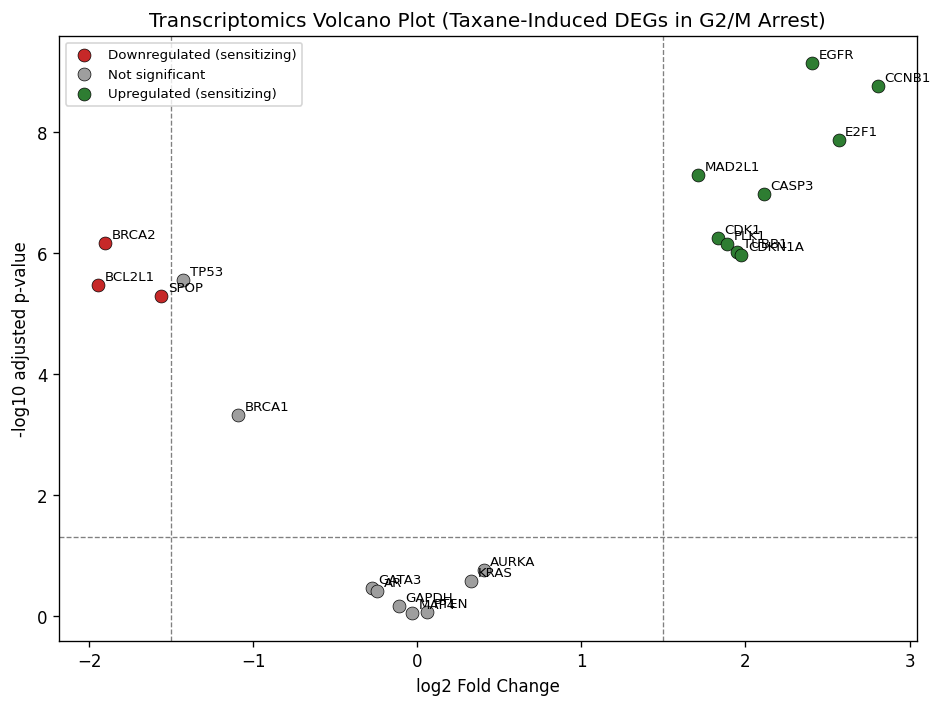

In [5]:
colors = {"Upregulated (sensitizing)": "#2e7d32",
          "Downregulated (sensitizing)": "#c62828",
          "Not significant": "#9e9e9e"}

fig, ax = plt.subplots(figsize=(8, 6))
for call_type, sub in deg.groupby("call"):
    ax.scatter(sub.log2FC, sub.neglog10p, c=colors[call_type], label=call_type,
               edgecolor="black", linewidth=0.4, s=60, zorder=3)

for _, r in deg.iterrows():
    ax.annotate(r.gene, (r.log2FC, r.neglog10p), fontsize=8, xytext=(4, 3),
                textcoords="offset points")

ax.axvline(FC_THRESH, ls="--", c="gray", lw=0.8)
ax.axvline(-FC_THRESH, ls="--", c="gray", lw=0.8)
ax.axhline(-np.log10(P_THRESH), ls="--", c="gray", lw=0.8)
ax.set_xlabel("log2 Fold Change")
ax.set_ylabel("-log10 adjusted p-value")
ax.set_title("Transcriptomics Volcano Plot (Taxane-Induced DEGs in G2/M Arrest)")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig("figure2_deg_volcano.png", dpi=300)
plt.show()


## 5. Export

Saves the DEG table and figure for downstream use in Notebook 05 (manuscript dashboard).

In [6]:
deg.to_csv("deg_results.csv", index=False)
print("Saved: deg_results.csv, figure2_deg_volcano.png")


Saved: deg_results.csv, figure2_deg_volcano.png


---
### Next steps for a real manuscript
- Swap in TCGA-BRCA/OV/LUAD/PRAD RNA-seq (tumor vs. matched normal, or pre/post-taxane if a longitudinal
  cohort is available) via `TCGAbiolinks` or GDC API.
- Run actual DESeq2 (R) or `pydeseq2` on raw counts rather than the t-test approximation used here.
- Validate the DEG calls against an independent GEO series before drawing mechanistic conclusions.
